In [1]:
from sklearn.model_selection import TimeSeriesSplit

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.preprocessing import StandardScaler

import joblib


In [2]:
import pandas as pd
df = pd.read_excel(
    "MCRFPUS1m.xls"
)
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,NaN,Workbook Contents,NaN,NaN,NaN,NaN
1,NaN,U.S. Field Production of Crude Oil (Thousand B...,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Click worksheet name or tab at bottom for data,NaN,NaN,NaN,NaN
4,NaN,Worksheet Name,Description,# Of Series,Frequency,Latest Data for


In [3]:
df = pd.read_excel(
    "MCRFPUS1m.xls",
    sheet_name="Data 1"
)

df.head()

,Back to Contents,Data 1: U.S. Field Production of Crude Oil (Thousand Barrels)
0,Sourcekey,MCRFPUS1
1,Date,U.S. Field Production of Crude Oil (Thousand B...
2,1920-01-15 00:00:00,34008
3,1920-02-15 00:00:00,33193
4,1920-03-15 00:00:00,36171


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1277 entries, 0 to 1276
Data columns (total 2 columns):
 #   Column                                                         Non-Null Count  Dtype 
---  ------                                                         --------------  ----- 
 0   Back to Contents                                               1277 non-null   object
 1   Data 1: U.S. Field Production of Crude Oil (Thousand Barrels)  1277 non-null   object
dtypes: object(2)
memory usage: 20.1+ KB


In [5]:
print(df.dtypes)

Back to Contents                                                 object
Data 1: U.S. Field Production of Crude Oil (Thousand Barrels)    object
dtype: object


In [6]:
df.head(10)

,Back to Contents,Data 1: U.S. Field Production of Crude Oil (Thousand Barrels)
0,Sourcekey,MCRFPUS1
1,Date,U.S. Field Production of Crude Oil (Thousand B...
2,1920-01-15 00:00:00,34008
3,1920-02-15 00:00:00,33193
4,1920-03-15 00:00:00,36171
5,1920-04-15 00:00:00,34945
6,1920-05-15 00:00:00,36622
7,1920-06-15 00:00:00,36663
8,1920-07-15 00:00:00,37746
9,1920-08-15 00:00:00,38906


In [7]:
import pandas as pd

df = pd.read_excel(
    "MCRFPUS1m.xls",
    sheet_name="Data 1"
)

df.columns = ["Date", "Production"]

# Remove first two metadata rows
df = df.iloc[2:]

# Remove the row containing the word "Date"
df = df[df["Date"] != "Date"]

# Convert data types
df["Date"] = pd.to_datetime(df["Date"])
df["Production"] = pd.to_numeric(df["Production"])

# Reset index
df.reset_index(drop=True, inplace=True)

df.head()

,Date,Production
0,1920-01-15,34008
1,1920-02-15,33193
2,1920-03-15,36171
3,1920-04-15,34945
4,1920-05-15,36622


In [8]:
df.isnull().sum()

Date          0
Production    0
dtype: int64

In [9]:
print(df.dtypes)

Date          datetime64[us]
Production             int64
dtype: object


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        1275 non-null   datetime64[us]
 1   Production  1275 non-null   int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 20.1 KB


In [11]:
print(f"Shape: {df.shape}")

Shape: (1275, 2)


In [12]:
print(df["Date"].min())
print(df["Date"].max())

1920-01-15 00:00:00
2026-03-15 00:00:00


In [13]:
df.describe()

,Date,Production
count,1275,1275.000000
mean,1973-02-13 08:51:57.176470,199370.100392
min,1920-01-15 00:00:00,33193.000000
25%,1946-07-30 12:00:00,145468.500000
50%,1973-02-15 00:00:00,201763.000000
75%,1999-08-30 12:00:00,259583.500000
max,2026-03-15 00:00:00,429777.000000
std,NaN,86379.860990


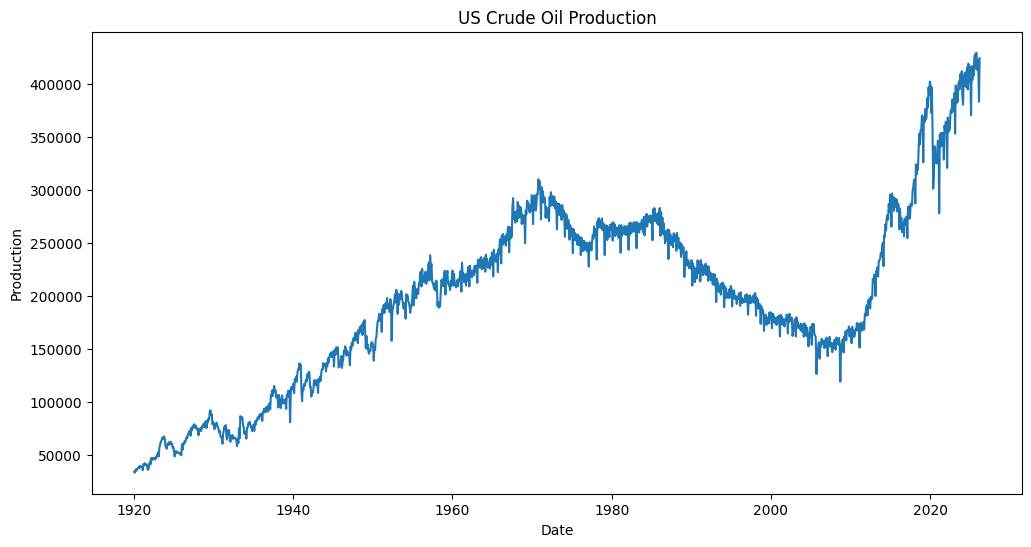

In [14]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Production"])
plt.xlabel("Date")
plt.ylabel("Production")
plt.title("US Crude Oil Production")
plt.show()

In [15]:
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

In [16]:
df.head()

,Date,Production,Month,Year
0,1920-01-15,34008,1,1920
1,1920-02-15,33193,2,1920
2,1920-03-15,36171,3,1920
3,1920-04-15,34945,4,1920
4,1920-05-15,36622,5,1920


In [17]:
monthly_avg = df.groupby("Month")["Production"].mean()
print(monthly_avg)

Month
1     202450.214953
2     186021.074766
3     205026.775701
4     196275.971698
5     201593.405660
6     195203.235849
7     201421.952830
8     202025.433962
9     195476.075472
10    203708.216981
11    198481.594340
12    204800.764151
Name: Production, dtype: float64


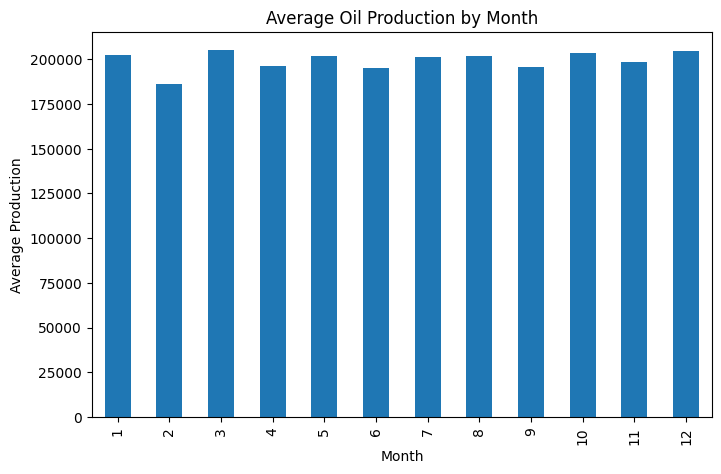

In [18]:
monthly_avg.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Oil Production by Month")
plt.xlabel("Month")
plt.ylabel("Average Production")
plt.show()

In [19]:
df["lag_1"] = df["Production"].shift(1)
df[["Date", "Production", "lag_1"]].head(10)

,Date,Production,lag_1
0,1920-01-15,34008,NaN
1,1920-02-15,33193,34008.0
2,1920-03-15,36171,33193.0
3,1920-04-15,34945,36171.0
4,1920-05-15,36622,34945.0
5,1920-06-15,36663,36622.0
6,1920-07-15,37746,36663.0
7,1920-08-15,38906,37746.0
8,1920-09-15,37521,38906.0
9,1920-10-15,39584,37521.0


In [20]:
df["lag_3"] = df["Production"].shift(3)
df["lag_6"] = df["Production"].shift(6)
df["lag_12"] = df["Production"].shift(12)

In [21]:
df[
    ["Date",
     "Production",
     "lag_1",
     "lag_3",
     "lag_6",
     "lag_12"]
].head(15)

,Date,Production,lag_1,lag_3,lag_6,lag_12
0,1920-01-15,34008,NaN,NaN,NaN,NaN
1,1920-02-15,33193,34008.0,NaN,NaN,NaN
2,1920-03-15,36171,33193.0,NaN,NaN,NaN
3,1920-04-15,34945,36171.0,34008.0,NaN,NaN
4,1920-05-15,36622,34945.0,33193.0,NaN,NaN
5,1920-06-15,36663,36622.0,36171.0,NaN,NaN
6,1920-07-15,37746,36663.0,34945.0,34008.0,NaN
7,1920-08-15,38906,37746.0,36622.0,33193.0,NaN
8,1920-09-15,37521,38906.0,36663.0,36171.0,NaN
9,1920-10-15,39584,37521.0,37746.0,34945.0,NaN


In [22]:
df["rolling_mean_3"] = df["Production"].rolling(3).mean()

df[
    ["Date",
     "Production",
     "rolling_mean_3"]
].head(10)

,Date,Production,rolling_mean_3
0,1920-01-15,34008,NaN
1,1920-02-15,33193,NaN
2,1920-03-15,36171,34457.333333
3,1920-04-15,34945,34769.666667
4,1920-05-15,36622,35912.666667
5,1920-06-15,36663,36076.666667
6,1920-07-15,37746,37010.333333
7,1920-08-15,38906,37771.666667
8,1920-09-15,37521,38057.666667
9,1920-10-15,39584,38670.333333


In [23]:
df["rolling_mean_6"] = df["Production"].rolling(6).mean()

df["rolling_mean_12"] = df["Production"].rolling(12).mean()

In [24]:
df.isnull().sum

<bound method DataFrame.sum of        Date  Production  Month   Year  lag_1  lag_3  lag_6  lag_12  \
0     False       False  False  False   True   True   True    True   
1     False       False  False  False  False   True   True    True   
2     False       False  False  False  False   True   True    True   
3     False       False  False  False  False  False   True    True   
4     False       False  False  False  False  False   True    True   
...     ...         ...    ...    ...    ...    ...    ...     ...   
1270  False       False  False  False  False  False  False   False   
1271  False       False  False  False  False  False  False   False   
1272  False       False  False  False  False  False  False   False   
1273  False       False  False  False  False  False  False   False   
1274  False       False  False  False  False  False  False   False   

      rolling_mean_3  rolling_mean_6  rolling_mean_12  
0               True            True             True  
1               

In [25]:
df.isnull().sum()

Date                0
Production          0
Month               0
Year                0
lag_1               1
lag_3               3
lag_6               6
lag_12             12
rolling_mean_3      2
rolling_mean_6      5
rolling_mean_12    11
dtype: int64

In [26]:
df.dropna()

,Date,Production,Month,Year,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_mean_12
12,1921-01-15,38138,1,1921,38961.0,39584.0,37746.0,34008.0,38569.333333,38619.833333,37254.916667
13,1921-02-15,35524,2,1921,38138.0,38609.0,38906.0,33193.0,37541.000000,38056.166667,37449.166667
14,1921-03-15,41105,3,1921,35524.0,38961.0,37521.0,36171.0,38255.666667,38653.500000,37860.333333
15,1921-04-15,40233,4,1921,41105.0,38138.0,39584.0,34945.0,38954.000000,38761.666667,38301.000000
16,1921-05-15,42189,5,1921,40233.0,35524.0,38609.0,36622.0,41175.666667,39358.333333,38764.916667
...,...,...,...,...,...,...,...,...,...,...,...
1270,2025-11-15,413677,11,2025,429777.0,428114.0,416844.0,401875.0,419433.000000,419942.333333,412676.833333
1271,2025-12-15,423356,12,2025,413677.0,414845.0,408315.0,416555.0,422270.000000,422449.166667,413243.583333
1272,2026-01-15,412456,1,2026,423356.0,429777.0,424926.0,407352.0,416496.333333,420370.833333,413668.916667
1273,2026-02-15,383507,2,2026,412456.0,413677.0,428114.0,370707.0,406439.666667,412936.333333,414735.583333


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             1275 non-null   datetime64[us]
 1   Production       1275 non-null   int64         
 2   Month            1275 non-null   int32         
 3   Year             1275 non-null   int32         
 4   lag_1            1274 non-null   float64       
 5   lag_3            1272 non-null   float64       
 6   lag_6            1269 non-null   float64       
 7   lag_12           1263 non-null   float64       
 8   rolling_mean_3   1273 non-null   float64       
 9   rolling_mean_6   1270 non-null   float64       
 10  rolling_mean_12  1264 non-null   float64       
dtypes: datetime64[us](1), float64(7), int32(2), int64(1)
memory usage: 99.7 KB


In [28]:
df.head()

,Date,Production,Month,Year,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_mean_12
0,1920-01-15,34008,1,1920,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1920-02-15,33193,2,1920,34008.0,NaN,NaN,NaN,NaN,NaN,NaN
2,1920-03-15,36171,3,1920,33193.0,NaN,NaN,NaN,34457.333333,NaN,NaN
3,1920-04-15,34945,4,1920,36171.0,34008.0,NaN,NaN,34769.666667,NaN,NaN
4,1920-05-15,36622,5,1920,34945.0,33193.0,NaN,NaN,35912.666667,NaN,NaN


In [29]:
df = df[df["Date"] >= "1980-01-01"].copy()
df.reset_index(drop=True, inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             555 non-null    datetime64[us]
 1   Production       555 non-null    int64         
 2   Month            555 non-null    int32         
 3   Year             555 non-null    int32         
 4   lag_1            555 non-null    float64       
 5   lag_3            555 non-null    float64       
 6   lag_6            555 non-null    float64       
 7   lag_12           555 non-null    float64       
 8   rolling_mean_3   555 non-null    float64       
 9   rolling_mean_6   555 non-null    float64       
 10  rolling_mean_12  555 non-null    float64       
dtypes: datetime64[us](1), float64(7), int32(2), int64(1)
memory usage: 43.5 KB


In [30]:
print(df["Date"].min())
print(df["Date"].max())
print(df.shape)

1980-01-15 00:00:00
2026-03-15 00:00:00
(555, 11)


In [31]:
features = [
    "Month",
    "Year",
    "lag_1",
    "lag_3",
    "lag_6",
    "lag_12",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_mean_12"
]

X = df[features]

y = df["Production"]

In [32]:
print(X.shape)
print(y.shape)
X.head()

(555, 9)
(555,)


,Month,Year,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_mean_12
0,1,1980,267050.0,267256.0,259278.0,262716.0,266269.333333,264456.333333,260627.833333
1,2,1980,268940.0,262818.0,264981.0,238710.0,262807.000000,262364.666667,261771.250000
2,3,1980,252431.0,267050.0,255693.0,266635.0,263673.666667,264690.833333,262022.500000
3,4,1980,269650.0,268940.0,267256.0,256593.0,260874.000000,263571.666667,262351.500000
4,5,1980,260541.0,252431.0,262818.0,266631.0,265958.333333,264382.666667,262439.250000


In [33]:
corr = df[
    [
        "Production",
        "lag_1",
        "lag_3",
        "lag_6",
        "lag_12",
        "rolling_mean_3",
        "rolling_mean_6",
        "rolling_mean_12"
    ]
].corr()

corr

,Production,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_mean_12
Production,1.000000,0.983137,0.983083,0.971755,0.966963,0.994955,0.992621,0.986696
lag_1,0.983137,1.000000,0.985616,0.981280,0.956386,0.994094,0.992812,0.988671
lag_3,0.983083,0.985616,1.000000,0.982804,0.967375,0.989263,0.993714,0.991606
lag_6,0.971755,0.981280,0.982804,1.000000,0.970358,0.983076,0.987634,0.992661
lag_12,0.966963,0.956386,0.967375,0.970358,1.000000,0.967851,0.973248,0.982567
rolling_mean_3,0.994955,0.994094,0.989263,0.983076,0.967851,1.000000,0.998392,0.993913
rolling_mean_6,0.992621,0.992812,0.993714,0.987634,0.973248,0.998392,1.000000,0.997378
rolling_mean_12,0.986696,0.988671,0.991606,0.992661,0.982567,0.993913,0.997378,1.000000


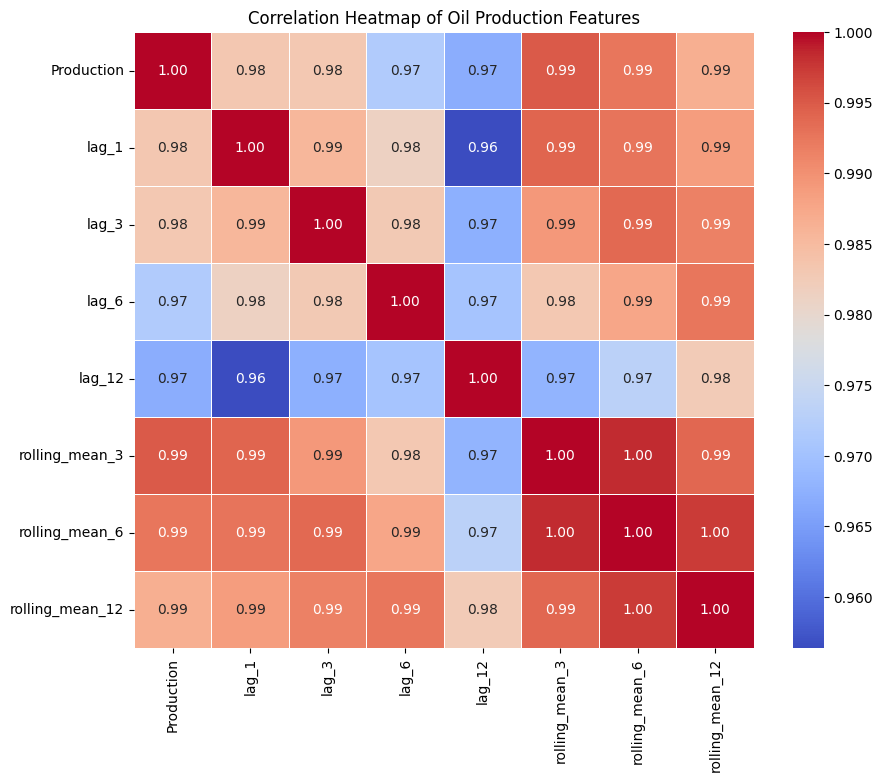

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[
    [
        "Production",
        "lag_1",
        "lag_3",
        "lag_6",
        "lag_12",
        "rolling_mean_3",
        "rolling_mean_6",
        "rolling_mean_12"
    ]
].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,      # show numbers
    fmt=".2f",       # 2 decimal places
    cmap="coolwarm", # color scheme
    linewidths=0.5
)

plt.title("Correlation Heatmap of Oil Production Features")
plt.show()

In [35]:
tscv = TimeSeriesSplit(n_splits=5)

In [36]:
for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
    
    print(f"\nSplit {i+1}")
    
    print("Train Size:", len(train_idx))
    print("Test Size :", len(test_idx))
    
    print("Train End Index:", train_idx[-1])
    print("Test Start Index:", test_idx[0])


Split 1
Train Size: 95
Test Size : 92
Train End Index: 94
Test Start Index: 95

Split 2
Train Size: 187
Test Size : 92
Train End Index: 186
Test Start Index: 187

Split 3
Train Size: 279
Test Size : 92
Train End Index: 278
Test Start Index: 279

Split 4
Train Size: 371
Test Size : 92
Train End Index: 370
Test Start Index: 371

Split 5
Train Size: 463
Test Size : 92
Train End Index: 462
Test Start Index: 463


In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled.shape)

(555, 9)


In [38]:
print(X_scaled[:5])

[[-1.58301992 -1.69470018  0.33373883  0.34585158  0.25251476  0.33552311
   0.32429819  0.30757222  0.27165035]
 [-1.29391954 -1.69470018  0.35949051  0.28489312  0.33217252 -0.01116037
   0.27690427  0.27868973  0.2877435 ]
 [-1.00481916 -1.69470018  0.13455164  0.34302205  0.20244058  0.39211948
   0.28876758  0.31081028  0.29127975]
 [-0.71571878 -1.69470018  0.36916442  0.36898228  0.36394903  0.24709759
   0.25044452  0.29535642  0.29591029]
 [-0.4266184  -1.69470018  0.24505223  0.14222174  0.3019604   0.39206171
   0.32004109  0.306555    0.29714534]]


In [39]:
mae_scores = []
mse_scores = []
r2_scores = []

In [47]:
for train_idx, test_idx in tscv.split(X):
print("Train: ", len(train_idx))
print("Test: ", len(test_idx))
break

IndentationError: expected an indented block after 'for' statement on line 1 (3630036567.py, line 2)

In [ ]:
for train_idx, test_idx in tscv.split(X):
    
    print("TRAIN:", len(train_idx))
    print("TEST :", len(test_idx))
    
    break

In [48]:
for train_idx, test_idx in tscv.split(X):
    
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    break

In [49]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(95, 9)
(92, 9)
(95,)
(92,)


In [50]:
scaler = StandardScaler()

In [51]:
X_train_scaled = scaler.fit_transform(X_train)

In [52]:
X_test_scaled = scaler.transform(X_test)

In [53]:
model = linearRegression()

NameError: name 'linearRegression' is not defined

In [54]:
model = LinearRegression()

In [55]:
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
y_pred = model.predict(
    x_test_scaled)

In [ ]:
y_pred = model.predict(
    X_test_scaled
)

In [56]:
y_pred = model.predict(
    X_test_scaled
)

In [57]:
print(y_pred[:10])

[255774.34797302 258806.60967903 240743.29108287 258713.92163715
 247385.32051199 254638.47127688 245328.17621719 249070.57165926
 247272.47199436 237248.21345759]


In [58]:
mae = mean_absolute_error(
    y_test,
    y_pred
)
print("MAE: ", mae)

MAE:  4114.158547226025


In [1]:
rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

print("RMSE:", rmse)

NameError: name 'mean_squared_error' is not defined

In [2]:
r2 = r2_score (
    y_test,
    y_pred
)
print("R2_Score: ", r2)

NameError: name 'r2_score' is not defined

In [3]:
import pandas as pd 
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "predicted": y_pred
})
comparison.head(10)

NameError: name 'y_test' is not defined

In [4]:
for train_idx, test_idx in tscv.split(X):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)

    X_test_scaled = scaler.transform(X_test)

    model = LinearRegression()

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)

    rmse = mean_squared_error(
        y_test,
        y_pred
    ) ** 0.5

    r2 = r2_score(
        y_test,
        y_pred
    )

    mae_scores.append(mae)

    rmse_scores.append(rmse)

    r2_scores.append(r2)

NameError: name 'tscv' is not defined

In [5]:
mae_scores = []
rmse_scores = []
r2_scores = []

In [6]:
for train_idx, test_idx in tscv.split(X):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LinearRegression()

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)

    rmse = mean_squared_error(y_test, y_pred) ** 0.5

    r2 = r2_score(y_test, y_pred)

    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

NameError: name 'tscv' is not defined

In [7]:
print("MAE Scores:")
print(mae_scores)

print("\nRMSE Scores:")
print(rmse_scores)

print("\nR2 Scores:")
print(r2_scores)

MAE Scores:
[]

RMSE Scores:
[]

R2 Scores:
[]


In [8]:
print("Average MAE :", sum(mae_scores) / len(mae_scores))
print("Average RMSE :", sum(rmse_scores) / len(rmse_scores))
print("Average R2 :", sum(r2_scores) / len(r2_scores))

ZeroDivisionError: division by zero

In [9]:
from sklearn.ensemble import RandomForestRegressor

In [10]:
rf_mae_scores = []
rf_rmse_scores = []
rf_r2_scores = []

In [11]:
for train_idx, test_idx in tscv.split(X):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model = RandomForestRressor(
    n_estimates = 100, 
    random_state = 42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
     mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = mean_squared_error(
        y_test,
        y_pred
    ) ** 0.5

    r2 = r2_score(
        y_test,
        y_pred
    )
rf_mae_scores.append(mae)
rf_rmse_scores.append(rmse)
rf_r2_scores.append(r2_scores)

IndentationError: unexpected indent (3079007169.py, line 15)

In [12]:
for train_idx, test_idx in tscv.split(X):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = mean_squared_error(
        y_test,
        y_pred
    ) ** 0.5

    r2 = r2_score(
        y_test,
        y_pred
    )

    rf_mae_scores.append(mae)
    rf_rmse_scores.append(rmse)
    rf_r2_scores.append(r2)

NameError: name 'tscv' is not defined

In [ ]:
print("RF MAE:", rf_mae_scores)

print("RF RMSE:", rf_rmse_scores)

print("RF R2:", rf_r2_scores)

In [13]:
print(
    "RF Average MAE:",
    sum(rf_mae_scores) / len(rf_mae_scores)
)

print(
    "RF Average RMSE:",
    sum(rf_rmse_scores) / len(rf_rmse_scores)
)

print(
    "RF Average R2:",
    sum(rf_r2_scores) / len(rf_r2_scores)
)

ZeroDivisionError: division by zero

In [14]:
print(X.shape)

NameError: name 'X' is not defined

In [15]:
print(X.shape)
print(df.shape)

NameError: name 'X' is not defined

In [16]:
import xgboost as xgb

In [17]:
xgb_mae_scores = []
xgb_rmse_scores = []
xgb_r2_scores = []

In [18]:
for train_idx, test_idx in tscv.split(X):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)

    rmse = mean_squared_error(
        y_test,
        y_pred
    ) ** 0.5

    r2 = r2_score(
        y_test,
        y_pred
    )

    xgb_mae_scores.append(mae)
    xgb_rmse_scores.append(rmse)
    xgb_r2_scores.append(r2)

NameError: name 'tscv' is not defined

In [19]:
print("XGB MAE:", xgb_mae_scores)

print("XGB RMSE:", xgb_rmse_scores)

print("XGB R2:", xgb_r2_scores)

XGB MAE: []
XGB RMSE: []
XGB R2: []


In [20]:
print(
    "XGB Average MAE:",
    sum(xgb_mae_scores) / len(xgb_mae_scores)
)

print(
    "XGB Average RMSE:",
    sum(xgb_rmse_scores) / len(xgb_rmse_scores)
)

print(
    "XGB Average R2:",
    sum(xgb_r2_scores) / len(xgb_r2_scores)
)

ZeroDivisionError: division by zero

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df,
    x="Abs_Coefficient",
    y="Feature"
)

plt.title("Feature Importance (Absolute Coefficients)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

NameError: name 'X' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df,
    x="Abs_Coefficient",
    y="Feature"
)

plt.title("Feature Importance (Absolute Coefficients)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

lr_model = LinearRegression()

lr_model.fit(X_scaled, y)

In [ ]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

coef_df

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df,
    x="Abs_Coefficient",
    y="Feature"
)

plt.title("Linear Regression Feature Importance")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")

plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(
    y_test.values,
    label="Actual"
)
plt.plot(
    y_pred, 
    label="Predicted"
)
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()
plt.show()

In [ ]:
print(len(y_test))
print(len(y_pred))

In [ ]:
print(y_test[:5])
print(y_pred[:5])

In [ ]:
comparison.head(10)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# First split only
for train_idx, test_idx in tscv.split(X):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    lr_model = LinearRegression()

    lr_model.fit(X_train_scaled, y_train)

    lr_pred = lr_model.predict(X_test_scaled)

    break

In [ ]:

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": lr_pred
})

comparison.head(10)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    lr_pred,
    label="Predicted"
)

plt.title("Linear Regression: Actual vs Predicted")

plt.xlabel("Observations")
plt.ylabel("Production")

plt.legend()
plt.savefig("Linear Regression: Actual vs Predicted")
plt.show()

In [ ]:
residuals = y_test.values - lr_pred
print("Residual mean: ", residuals.mean())
print("Residuals std: ", residuals.std())

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(
    residuals,
    bins = 20
)
plt.title("Residual distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [ ]:
print("Residual Mean:", residuals.mean())
print("Residual Median:", residuals.mean())

In [ ]:
from sklearn.linear_model import LinearRegression 
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
final_model = LinearRegression()
final_model.fit(X_scaled, y) 
print("Final Model Trained!")

In [ ]:
df.tail()

In [ ]:
history = list(df["Production"])
print("History length: ", len(history))
print("Last value: ", history[-1])

In [ ]:
future_dates = pd.data_range(
    start = df["Date"].max() + pd.DateOffset(months=1),
    periods=60,
    freq='MS'
)
future_dates 

In [ ]:
future_dates = pd.date_range(
    start = df["Date"].max() + pd.DateOffset(months=1),
    periods=60,
    freq='MS'
)
future_dates 

In [ ]:
future_predictions = []

In [ ]:
for date in future_dates:

In [ ]:
for date in future_dates:
    lag_1 = history[-1]
    lag_3 = history[-3]
    lag_6 = history[-6]
    lag_12 = history[-12]

In [ ]:
rolling_mean_3 = sum(history[-3:]) / 3

rolling_mean_6 = sum(history[-6:]) / 6

rolling_mean_12 = sum(history[-12:]) / 12

In [ ]:
for date in future_dates:

    # Lag Features
    lag_1 = history[-1]
    lag_3 = history[-3]
    lag_6 = history[-6]
    lag_12 = history[-12]

    # Rolling Means
    rolling_mean_3 = sum(history[-3:]) / 3
    rolling_mean_6 = sum(history[-6:]) / 6
    rolling_mean_12 = sum(history[-12:]) / 12

    # Date Features
    month = date.month
    year = date.year

    # Create feature row
    future_row = pd.DataFrame({
        "Month": [month],
        "Year": [year],
        "lag_1": [lag_1],
        "lag_3": [lag_3],
        "lag_6": [lag_6],
        "lag_12": [lag_12],
        "rolling_mean_3": [rolling_mean_3],
        "rolling_mean_6": [rolling_mean_6],
        "rolling_mean_12": [rolling_mean_12]
    })

    # Scale features
    future_row_scaled = scaler.transform(future_row)

    # Predict
    prediction = final_model.predict(future_row_scaled)[0]

    # Store prediction
    future_predictions.append(prediction)

    # Add prediction to history
    history.append(prediction)

In [ ]:
forecast_df = pd.DataFrame({

In [ ]:
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast": future_predictions
    )}

In [ ]:
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast": future_predictions
})

In [ ]:
forecast_df.head()

In [ ]:
forecast_df.tail()

In [ ]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(14, 6))

In [ ]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(14, 6))
plt.plot(
    df["Date"], 
    df["Production"],
    label="Historical Production"
)
plt.plot(
    df["Date"],
    df["Forecast"],
    label="Forecast (2026-2031)"
)
plt.title("U.S Crude Oil Production Foreacast (Next 5 years)")
plt.xlabel("Year")
plt.ylabel("Production")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

plt.plot(
    df["Date"],
    df["Production"],
    label="Historical Production"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecast"],
    label="Forecast (2026-2031)"
)

plt.title(
    "U.S. Crude Oil Production Forecast (Next 5 Years)"
)

plt.xlabel("Year")
plt.ylabel("Production")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
forecast_df.describe()

In [ ]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Production"])
plt.xlabel("Date")
plt.ylabel("Production")
plt.title("US Crude Oil Production")
plt.show()

In [ ]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Production"])
plt.xlabel("Date")
plt.ylabel("Production")
plt.title("US Crude Oil Production")
plt.savefig("US Crude Oil Production")
plt.show()

In [ ]:
monthly_avg.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Oil Production by Month")
plt.xlabel("Month")
plt.ylabel("Average Production")
plt.savefig("Monthly Trends of Oil Production")
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[
    [
        "Production",
        "lag_1",
        "lag_3",
        "lag_6",
        "lag_12",
        "rolling_mean_3",
        "rolling_mean_6",
        "rolling_mean_12"
    ]
].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,      # show numbers
    fmt=".2f",       # 2 decimal places
    cmap="coolwarm", # color scheme
    linewidths=0.5
)

plt.title("Correlation Heatmap of Oil Production Features")
plt.savefig("Correlation Heatmap")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df,
    x="Abs_Coefficient",
    y="Feature"
)

plt.title("Linear Regression Feature Importance")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.savefig("Linear Regression Feature Importance", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df,
    x="Abs_Coefficient",
    y="Feature"
)

plt.title("Linear Regression Feature Importance")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.savefig("Linear Regression Feature Importance", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df,
    x="Abs_Coefficient",
    y="Feature"
)

plt.title("Linear Regression Feature Importance")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")

plt.show()

In [ ]:
print(type(model))

In [ ]:
coef_df.head()

In [ ]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df["Abs_Coefficient"] = abs(coef_df["Coefficient"])

coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df,
    x="Abs_Coefficient",
    y="Feature"
)

plt.title("Linear Regression Feature Importance")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(
    y_test.values,
    label="Actual"
)
plt.plot(
    y_pred, 
    label="Predicted"
)
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()
plt.savefig("Linear Regression: Actual vs Predicted")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    lr_pred,
    label="Predicted"
)

plt.title("Linear Regression: Actual vs Predicted")

plt.xlabel("Observations")
plt.ylabel("Production")

plt.legend()
plt.savefig("Linear Regression: Actual vs Predicted")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    lr_pred,
    label="Predicted"
)

plt.title("Linear Regression: Actual vs Predicted")

plt.xlabel("Observations")
plt.ylabel("Production")

plt.legend()
plt.savefig("Linear Regression Actual vs Predicted.png")
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(
    residuals,
    bins = 20
)
plt.title("Residual distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.savefig("Residual distribution.png")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

plt.plot(
    df["Date"],
    df["Production"],
    label="Historical Production"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecast"],
    label="Forecast (2026-2031)"
)

plt.title(
    "U.S. Crude Oil Production Forecast (Next 5 Years)"
)

plt.xlabel("Year")
plt.ylabel("Production")

plt.legend()

plt.grid(True)
plt.savefig("U.S. Crude Oil Production Forecast.png")

plt.show()

In [ ]:
print("Notebook working")

In [ ]:
import statsmodels
print(statsmodels._version)

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

print("ARIMA Imported Successfully")

In [ ]:
from statsmodels.tsa.arima.model import ARIMA 
production = df["Production"]
arima_model = ARIMA(
    production, 
    order=(5, 1, 0)
)
arima_fit = arima_model.fit()
print("ARIMA Model trained Successfully")

In [ ]:
import pandas as pd

df = pd.read_excel(
    "MCRFPUS1m.xls",
    sheet_name="Data 1"
)

print(df.head())

In [ ]:
print(df.columns)

In [ ]:
df["Production"].head()

In [22]:
from statsmodels.tsa.arima.model import ARIMA

print("ARIMA Imported Successfully")

ARIMA Imported Successfully


In [23]:
from statsmodels.tsa.arima.model import ARIMA 
production = df["Production"]
arima_model = ARIMA(
    production, 
    order=(5, 1, 0)
)
arima_fit = arima_model.fit()
print("ARIMA Model trained Successfully")

NameError: name 'df' is not defined

In [40]:
from statsmodels.tsa.arima.model import ARIMA 
production = df["Production"]
arima_model = ARIMA(
    production, 
    order=(5, 1, 0)
)
arima_fit = arima_model.fit()
print("ARIMA Model trained Successfully")

ARIMA Model trained Successfully


In [41]:
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Production   No. Observations:                  555
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -5982.002
Date:                Fri, 12 Jun 2026   AIC                          11976.004
Time:                        20:04:49   BIC                          12001.907
Sample:                             0   HQIC                         11986.123
                                - 555                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4101      0.008    -49.489      0.000      -0.426      -0.394
ar.L2         -0.0915      0.015     -6.218      0.000      -0.120      -0.063
ar.L3         -0.0092      0.034     -0.275      0.7

In [42]:
residuals = arima_fit.residuals()
print(residuals.head())
print(residuals.shape)

AttributeError: 'ARIMAResults' object has no attribute 'residuals'

In [43]:
residuals = arima_fit.resid()
print(residuals.head())
print(residuals.shape)

TypeError: 'Series' object is not callable

In [44]:
residuals = arima_fit.resid()

print(residuals.head())
print(residuals.shape)

TypeError: 'Series' object is not callable

In [45]:
residuals = arima_fit.resid

print(residuals.head())
print(residuals.shape)

0    268940.000000
1     84150.535166
2     33423.681995
3      1838.073432
4      7419.620287
dtype: float64
(555,)


In [46]:
residuals.describe()

count       555.000000
mean        974.144530
std       16265.969701
min      -72164.122077
25%       -4012.110317
50%        1528.542738
75%        6157.899198
max      268940.000000
dtype: float64

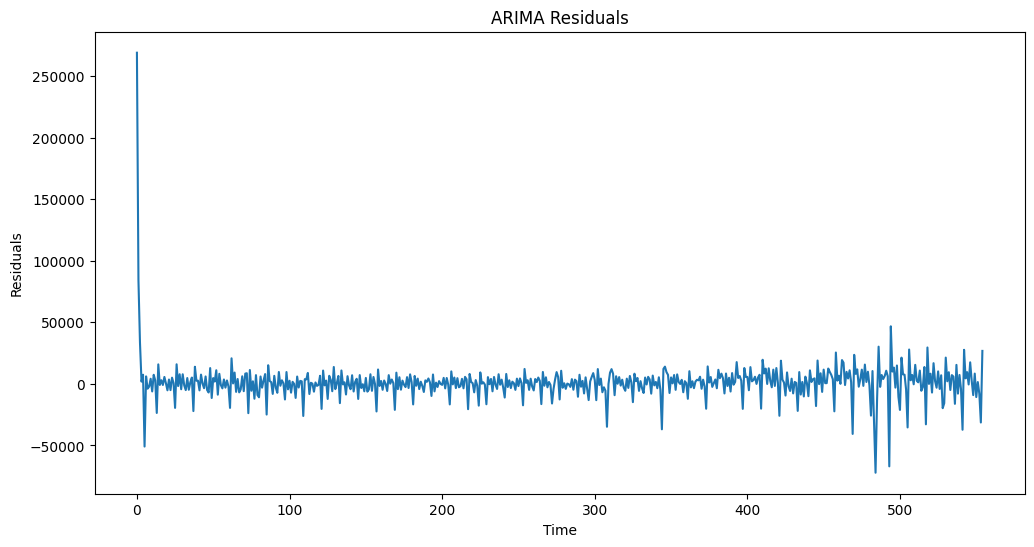

In [47]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(12, 6))
plt.plot(residuals)
plt.title("ARIMA Residuals")
plt.xlabel("Time")
plt.ylabel("Residuals")
plt.savefig(
            "ARIMA Residuals.png", 
            dpi = 300, 
            bbox_inches="tight"
)
plt.show()

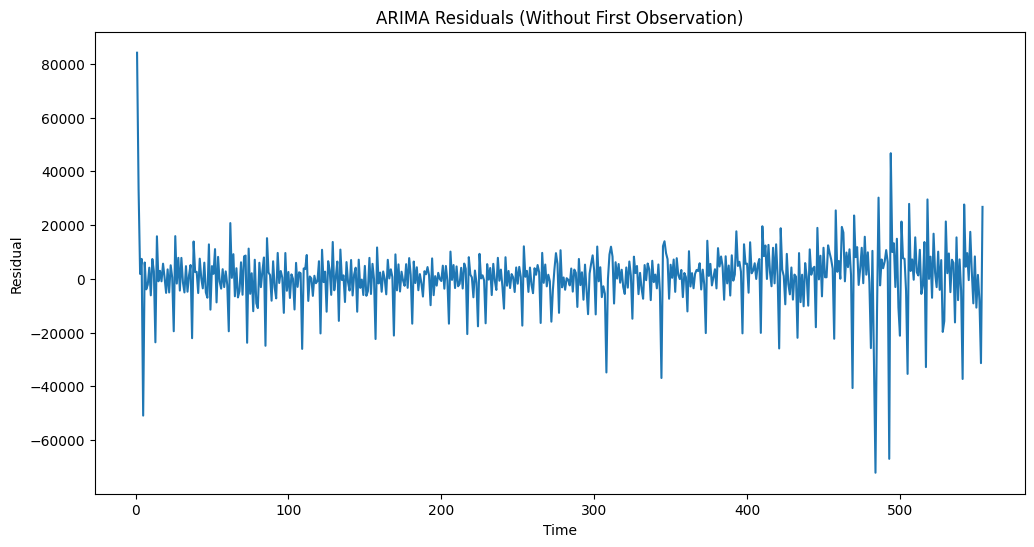

In [48]:
residuals_no_first = residuals[1:]

plt.figure(figsize=(12,6))

plt.plot(residuals_no_first)

plt.title("ARIMA Residuals (Without First Observation)")
plt.xlabel("Time")
plt.ylabel("Residual")

plt.show()

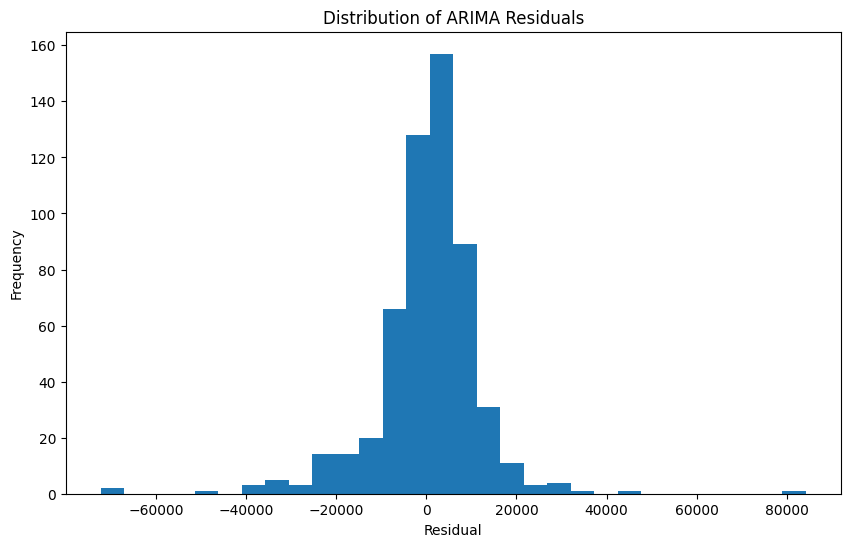

In [50]:
plt.figure(figsize=(10, 6))
plt.hist(residuals_no_first, bins=30)
plt.title("Distribution of ARIMA Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

In [51]:
forecast_arima = arima_fit.forecast(steps=60)
print(forecast_arima.head())
print(forecast_arima.tail())

555    408421.083294
556    412502.760729
557    408546.814167
558    407570.916766
559    414019.585312
Name: predicted_mean, dtype: float64
610    410502.906075
611    410502.905746
612    410502.906063
613    410502.905849
614    410502.905945
Name: predicted_mean, dtype: float64


In [52]:
train_size = int(len(df)*0.8)
train = df["Production"][:train_size]
test = df["Production"][train_size:]
print("Train:", train.shape)
print("Test:", test.shape)

Train: (444,)
Test: (111,)


In [53]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(
    train,
    order=(5,1,0)
)

arima_fit = arima_model.fit()

print("ARIMA trained")

ARIMA trained


In [54]:
arima_pred = arima_model.forecast(
    steps=len(test)
)
print(arima_pred.head())

AttributeError: 'ARIMA' object has no attribute 'forecast'

In [55]:
arima_pred = arima_fit.forecast(
    steps=len(test)
)

print(arima_pred.head())

444    271556.878638
445    270860.440708
446    272798.218894
447    271656.104520
448    272641.649065
Name: predicted_mean, dtype: float64


In [56]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    test,
    arima_pred
)

rmse = mean_squared_error(
    test,
    arima_pred
) ** 0.5

r2 = r2_score(
    test,
    arima_pred
)

print("ARIMA MAE :", mae)
print("ARIMA RMSE:", rmse)
print("ARIMA R2 :", r2)

ARIMA MAE : 91189.81092210222
ARIMA RMSE: 100353.14567822036
ARIMA R2 : -4.555726687281983


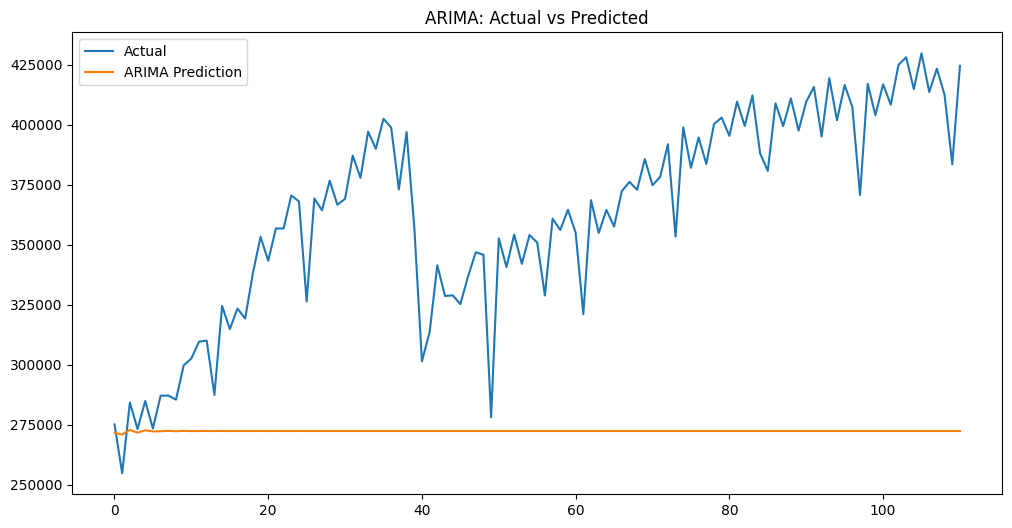

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(test.values, label="Actual")
plt.plot(arima_pred.values, label="ARIMA Prediction")

plt.legend()

plt.title("ARIMA: Actual vs Predicted")
plt.show()

In [58]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(
    train,
    order=(2,1,2)
)

arima_fit = arima_model.fit()

print("ARIMA trained")

C:\Users\khushi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\khushi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\khushi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA trained


In [59]:
arima_pred = arima_fit.forecast(
    steps=len(test)
)

print(arima_pred.head())

444    271036.188525
445    268041.297019
446    275605.410768
447    265493.569120
448    275452.869816
Name: predicted_mean, dtype: float64


In [60]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    test,
    arima_pred
)

rmse = mean_squared_error(
    test,
    arima_pred
) ** 0.5

r2 = r2_score(
    test,
    arima_pred
)

print("ARIMA MAE :", mae)
print("ARIMA RMSE:", rmse)
print("ARIMA R2 :", r2)

ARIMA MAE : 92563.52554354207
ARIMA RMSE: 101487.5171178887
ARIMA R2 : -4.682038171668967


In [61]:
print("notebook working")

notebook working


In [62]:
from statsmodel.tsa.stattools import adfuller
result = adfuller(df["Production"])
print("ADF Statistics: ", result[0])
print("p-value: ", result[1])

ModuleNotFoundError: No module named 'statsmodel'

In [63]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df["Production"])
print("ADF Statistics: ", result[0])
print("p-value: ", result[1])

ADF Statistics:  0.15926855262839856
p-value:  0.9698823021896382


In [64]:
production_diff = df["Production"].diff()
production_diff = production_diff.dropna()
print(production_diff.head())

1   -16509.0
2    17219.0
3    -9109.0
4     7143.0
5   -11065.0
Name: Production, dtype: float64


In [65]:
result = adfuller(production_diff)
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -4.7591277240866345
p-value: 6.507120811465534e-05


In [66]:
print("working")

working


<Figure size 1000x500 with 0 Axes>

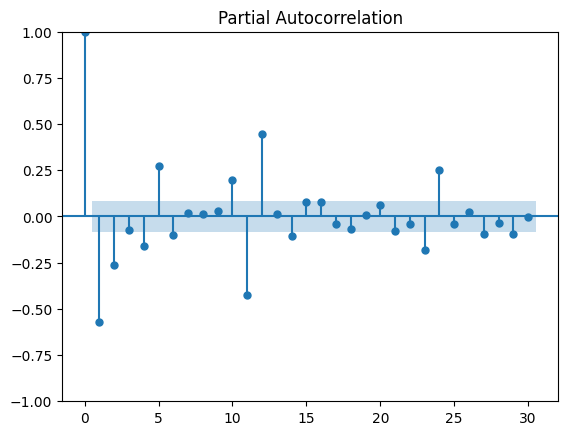

In [67]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plot_pacf(
    production_diff,
    lags=30
)

plt.show()

<Figure size 1000x500 with 0 Axes>

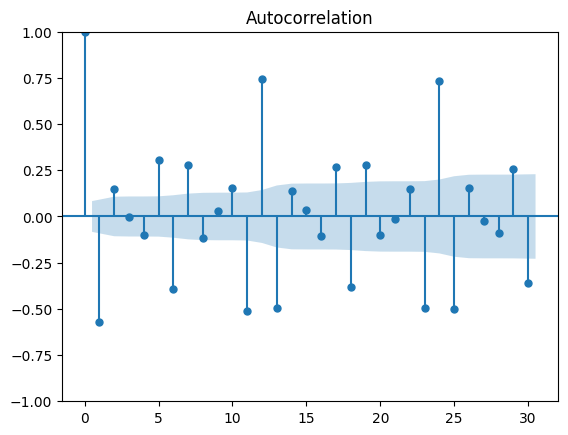

In [68]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plot_acf(
    production_diff,
    lags=30
)

plt.show()

In [73]:
print("working")

working


In [74]:
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

best_aic = float("inf")
best_order = None

for p in range(0, 6):
    for d in range(1, 2):   # we know d=1
        for q in range(0, 6):

            try:
                model = ARIMA(
                    train,
                    order=(p,d,q)
                )

                fit = model.fit()

                if fit.aic < best_aic:
                    best_aic = fit.aic
                    best_order = (p,d,q)

            except:
                continue

print("Best Order:", best_order)
print("Best AIC:", best_aic)

Best Order: (5, 1, 3)
Best AIC: 119.68341852606349


In [75]:
print(best_order)
print(best_aic)

(5, 1, 3)
119.68341852606349


In [76]:
print(type(train))
print(len(train))

<class 'pandas.Series'>
444


In [79]:
print(train.head())
print(train.tail())

0    268940
1    252431
2    269650
3    260541
4    267684
Name: Production, dtype: int64
439    269530
440    256412
441    273066
442    267228
443    273413
Name: Production, dtype: int64


In [78]:
print(train.min())
print(train.max())

119208
296966


In [80]:
print(len(train))
print(len(test))

444
111


In [83]:
best_model = ARIMA(
    train,
    order=(5,1,3)
)

best_fit = best_model.fit()

print("Best ARIMA trained successfully")

Best ARIMA trained successfully


In [84]:
arima_pred = best_fit.forecast(
    steps=len(test)
)

print(arima_pred.head())
print(arima_pred.shape)

444    4.439771e+09
445   -5.914222e+09
446    6.972330e+09
447   -8.561127e+09
448    9.421371e+09
Name: predicted_mean, dtype: float64
(111,)


In [85]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(
    test,
    arima_pred
)

rmse = mean_squared_error(
    test,
    arima_pred
) ** 0.5

r2 = r2_score(
    test,
    arima_pred
)

print("ARIMA MAE :", mae)
print("ARIMA RMSE:", rmse)
print("ARIMA R2 :", r2)

ARIMA MAE : 13500331138.191051
ARIMA RMSE: 15125615635.448706
ARIMA R2 : -126213267986.77695


In [86]:
print(arima_pred.describe())

count    1.110000e+02
mean     2.448915e+09
std      1.499381e+10
min     -2.089425e+10
25%     -1.172742e+10
50%      2.522885e+09
75%      1.623004e+10
max      2.595067e+10
Name: predicted_mean, dtype: float64


In [87]:
print(best_fit.aic)

119.68341852606349


In [88]:
print(arima_pred.head())
print(arima_pred.tail())

444    4.439771e+09
445   -5.914222e+09
446    6.972330e+09
447   -8.561127e+09
448    9.421371e+09
Name: predicted_mean, dtype: float64
550    1.403391e+10
551   -1.374387e+10
552    1.589768e+10
553   -1.579480e+10
554    1.753659e+10
Name: predicted_mean, dtype: float64


In [89]:
print(best_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Production   No. Observations:                  444
Model:                 ARIMA(5, 1, 3)   Log Likelihood                 -50.842
Date:                Sat, 13 Jun 2026   AIC                            119.683
Time:                        19:20:44   BIC                            156.526
Sample:                             0   HQIC                           134.214
                                - 444                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9983      0.002    585.382      0.000       0.995       1.002
ar.L2          1.9848      0.002   1151.334      0.000       1.981       1.988
ar.L3         -1.9795      0.002  -1162.876      0.0

In [90]:
model = ARIMA(
    train,
    order=(1,1,1)
)

fit = model.fit()

pred = fit.forecast(
    steps=len(test)
)

print(pred.head())
print(pred.describe())

444    271546.810347
445    272072.944222
446    271924.611573
447    271966.430919
448    271954.640813
Name: predicted_mean, dtype: float64
count       111.000000
mean     271954.349432
std          40.683807
min      271546.810347
25%      271957.233763
50%      271957.233763
75%      271957.233763
max      272072.944222
Name: predicted_mean, dtype: float64


In [92]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(
    test,
    pred
)

rmse = mean_squared_error(
    test,
    pred
) ** 0.5

r2 = r2_score(
    test,
    pred
)

print("ARIMA(1,1,1) MAE :", mae)
print("ARIMA(1,1,1) RMSE:", rmse)
print("ARIMA(1,1,1) R2 :", r2)

ARIMA(1,1,1) MAE : 91569.19010340679
ARIMA(1,1,1) RMSE: 100697.3628332868
ARIMA(1,1,1) R2 : -4.593904986589861
